# 0 - Setup

In [ ]:

!pip install pytorch-tabnet
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from pytorch_tabnet.tab_model import TabNetClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 609.4 kB/s eta 0:00:00


### Import Dataset

In [ ]:
df = pd.read_csv("diabetes.csv")
df.head()

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Diabetes-ML-Project/data /diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 1 - Exploratory Data Analysis

In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nSummary stats:")
print(df.describe())

Shape: (768, 9)

Columns: Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Summary stats:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.00000

In [ ]:
(df == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


Above we checked for placeholders in the form of a 0. Looking at this we know it is resonable for someone to have 0 pregnancies, however the following are medically unrealistic: Glucose, BloodPressure, SkinThickness, Insulin, BMI. We will treat these are missing values .

In [ ]:
cols = [ 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df.fillna(df.median(), inplace = True)
df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


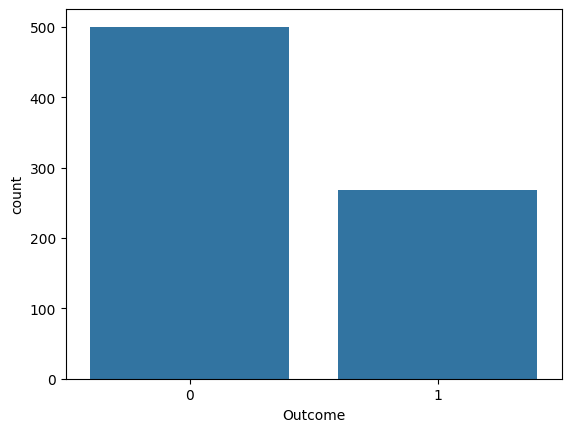

In [ ]:
sns.countplot(x='Outcome', data=df)
plt.show()

above we are checking the balance of our dataset, it is moderately imbalanced with a higher number of non-diabetic cases(outcome=0) compared to diabetic case(outcome=1). This imbalance may influence model performance, particularly for metrics such as accuracy.

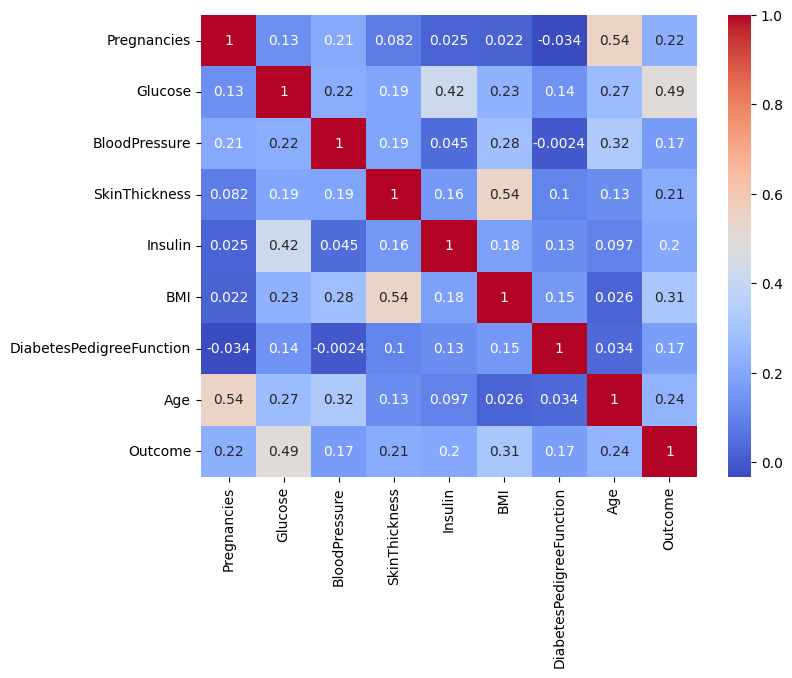

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

above is a heatmap which is a correlation matrix, looking at outcome since its what we are trying to predict, Glucose is the strongest predictor with BMI,Age, and Pregnancies being moderate.

# 3 - TabNet Model

In [ ]:
X = df.drop('Outcome', axis=1).to_numpy()
y = df['Outcome'].to_numpy()

In [ ]:
# first split: train+val vs test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# second split: train vs validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1
)

#fit the model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.93074 | val_auc: 0.38953 |  0:00:00s
epoch 1  | loss: 0.75293 | val_auc: 0.34578 |  0:00:00s
epoch 2  | loss: 0.69333 | val_auc: 0.60756 |  0:00:00s
epoch 3  | loss: 0.64063 | val_auc: 0.53837 |  0:00:00s
epoch 4  | loss: 0.64356 | val_auc: 0.50799 |  0:00:00s
epoch 5  | loss: 0.57887 | val_auc: 0.50959 |  0:00:00s
epoch 6  | loss: 0.5597  | val_auc: 0.4734  |  0:00:00s
epoch 7  | loss: 0.54625 | val_auc: 0.42936 |  0:00:01s
epoch 8  | loss: 0.52818 | val_auc: 0.41555 |  0:00:01s
epoch 9  | loss: 0.49025 | val_auc: 0.40756 |  0:00:01s
epoch 10 | loss: 0.50119 | val_auc: 0.42587 |  0:00:01s
epoch 11 | loss: 0.50271 | val_auc: 0.38692 |  0:00:01s
epoch 12 | loss: 0.49119 | val_auc: 0.41846 |  0:00:02s

Early stopping occurred at epoch 12 with best_epoch = 2 and best_val_auc = 0.60756


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


To improve performance  additional hyperparameter tuning may be explored later. Default tabnet parameters were used above.



In [ ]:
#predict
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]

In [ ]:
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.6558441558441559
Precision: 0.5079365079365079
Recall: 0.5925925925925926
F1 Score: 0.5470085470085471
ROC-AUC: 0.667962962962963


TabNet showed lower performance compared to expectations, with validation AUC peaking early and declining thereafter. This suggests potential overfitting or instability due to the relatively small dataset size.

Multiple evaluation metrics were used to assess model performance, including Accuracy, Precision, Recall, F1 Score, and ROC-AUC. While accuracy provides an overall measure, recall is emphasized due to the importance of correctly identifying diabetic cases.

Accuracy - Model correct predicts about 66% of cases


---


Precisions - when model predicts diabetes, it is correct about 51% of the time which indicates a relatively high number of false positives


---


Recall - Model correctly identifies abbout 59% of actual diabetic cases which means it misses about 41%


---


F1 Score - Shows moderate balance between precision and recall confirms the model is not performing strongly in either direction


---


Roc-Auc- indicates fair but not strong ability to distinguish between classes

# 4 - Parameter Tuning for TabNet ( n_d, n_A )

The baseline TabNet model was trained using default parameters on the Pima Indians Diabetes dataset,
achieving an accuracy of 66% and a recall of 0.59. Training was conducted on a relatively small
dataset of 768 samples with 8 features.

Since this is a medical prediction task, recall is the most important metric, as missing diabetic
patients (false negatives) is more critical than false positives. While the baseline provides a
starting point, improvements are needed to increase recall and reduce missed cases.

Further hyperparameter tuning (e.g., model size, learning rate, and steps) is justified to improve
performance on this small and noisy dataset. See below.

To ensure fair comparison across experiments, the same training, validation, and test splits were
kept fixed while only TabNet hyperparameters and training settings were adjusted.

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1,
    n_d=16,    #according to paper n_d = n_a is a reasonable choice for most datasets DEFAULT
    n_a=16,
)

#fit the model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.00836 | val_auc: 0.53343 |  0:00:00s
epoch 1  | loss: 0.78177 | val_auc: 0.5     |  0:00:00s
epoch 2  | loss: 0.657   | val_auc: 0.48547 |  0:00:00s
epoch 3  | loss: 0.60346 | val_auc: 0.37006 |  0:00:00s
epoch 4  | loss: 0.63153 | val_auc: 0.3891  |  0:00:00s
epoch 5  | loss: 0.51056 | val_auc: 0.55872 |  0:00:00s
epoch 6  | loss: 0.53948 | val_auc: 0.59826 |  0:00:01s
epoch 7  | loss: 0.53466 | val_auc: 0.57078 |  0:00:01s
epoch 8  | loss: 0.49688 | val_auc: 0.48299 |  0:00:01s
epoch 9  | loss: 0.60265 | val_auc: 0.49637 |  0:00:01s
epoch 10 | loss: 0.53205 | val_auc: 0.48328 |  0:00:01s
epoch 11 | loss: 0.53119 | val_auc: 0.47151 |  0:00:01s
epoch 12 | loss: 0.53914 | val_auc: 0.48328 |  0:00:01s
epoch 13 | loss: 0.50635 | val_auc: 0.48328 |  0:00:01s
epoch 14 | loss: 0.51018 | val_auc: 0.46512 |  0:00:02s
epoch 15 | loss: 0.48631 | val_auc: 0.47674 |  0:00:02s
epoch 16 | loss: 0.52395 | val_auc: 0.47674 |  0:00:02s

Early stopping occurred at epoch 16 with best_e

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
#predict
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.6883116883116883
Precision: 0.5576923076923077
Recall: 0.5370370370370371
F1 Score: 0.5471698113207547
ROC-AUC: 0.6009259259259259


Increasing the hidden dimension (n_d = n_a = 16) produced a slight increase in accuracy (0.66 → 0.69) and precision (0.51 → 0.56), however recall decreased from 0.59 to 0.54 and ROC-AUC dropped from 0.67 to 0.60. Since recall is the primary metric for this medical prediction task, this configuration is not an improvement. A larger embedding width does not benefit the Pima Indians dataset, likely because with only 8 features and 768 samples there is insufficient data for the model to take advantage of the increased model capacity. This mirrors the same finding from the Health Indicators dataset where increasing n_d also did not improve performance.

# 5 - Tuning Parameters (n_steps & gamma)

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1,
    n_steps=5,  #according to paper n_steps [3,10] is optimal. With only 8 features we use 5 as a midpoint
    gamma=1.5,  #according to paper larger n_steps favors a larger gamma
)

#fit the model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.33334 | val_auc: 0.42151 |  0:00:00s
epoch 1  | loss: 0.85865 | val_auc: 0.42994 |  0:00:00s
epoch 2  | loss: 0.80873 | val_auc: 0.70799 |  0:00:00s
epoch 3  | loss: 0.69315 | val_auc: 0.35218 |  0:00:00s
epoch 4  | loss: 0.62933 | val_auc: 0.325   |  0:00:00s
epoch 5  | loss: 0.66386 | val_auc: 0.29651 |  0:00:00s
epoch 6  | loss: 0.62402 | val_auc: 0.23198 |  0:00:00s
epoch 7  | loss: 0.5721  | val_auc: 0.2436  |  0:00:00s
epoch 8  | loss: 0.61545 | val_auc: 0.26017 |  0:00:00s
epoch 9  | loss: 0.56309 | val_auc: 0.36279 |  0:00:00s
epoch 10 | loss: 0.60095 | val_auc: 0.40087 |  0:00:00s
epoch 11 | loss: 0.60646 | val_auc: 0.53285 |  0:00:00s
epoch 12 | loss: 0.58657 | val_auc: 0.59738 |  0:00:00s

Early stopping occurred at epoch 12 with best_epoch = 2 and best_val_auc = 0.70799


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.6428571428571429
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.6615740740740741


Setting n_steps=5 and gamma=1.5 caused the model to completely collapse, predicting all cases as non-diabetic and resulting in precision, recall, and F1 scores of 0.0. While ROC-AUC remains at 0.66 due to probability scores still containing some signal, the model produces no useful predictions. This occurs because increasing the number of attention steps on a dataset with only 8 features and 768 samples causes the attention mechanism to become unstable — with too many steps and too few features, the model cannot learn meaningful feature selection and defaults to predicting the majority class. This result confirms that higher n_steps values recommended in the TabNet paper are designed for larger, richer datasets and are not appropriate for small tabular datasets like Pima Indians

# 6 - Tune Performance (batch_size)

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1,
)

#fit the model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=64,           #according to paper batch size should be 1-10% of dataset size. Pima is small so we use a smaller batch
    virtual_batch_size=32    #virtual batch size kept proportionally smaller than batch_size
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.73446 | val_auc: 0.43328 |  0:00:00s
epoch 1  | loss: 0.61561 | val_auc: 0.66613 |  0:00:00s
epoch 2  | loss: 0.55424 | val_auc: 0.69767 |  0:00:00s
epoch 3  | loss: 0.55105 | val_auc: 0.71541 |  0:00:01s
epoch 4  | loss: 0.56279 | val_auc: 0.68328 |  0:00:01s
epoch 5  | loss: 0.51973 | val_auc: 0.7282  |  0:00:01s
epoch 6  | loss: 0.495   | val_auc: 0.76613 |  0:00:01s
epoch 7  | loss: 0.48426 | val_auc: 0.79346 |  0:00:02s
epoch 8  | loss: 0.48517 | val_auc: 0.81265 |  0:00:02s
epoch 9  | loss: 0.46135 | val_auc: 0.75669 |  0:00:02s
epoch 10 | loss: 0.48297 | val_auc: 0.75451 |  0:00:02s
epoch 11 | loss: 0.5123  | val_auc: 0.6811  |  0:00:02s
epoch 12 | loss: 0.49681 | val_auc: 0.65145 |  0:00:03s
epoch 13 | loss: 0.51678 | val_auc: 0.60291 |  0:00:03s
epoch 14 | loss: 0.48866 | val_auc: 0.70523 |  0:00:03s
epoch 15 | loss: 0.44753 | val_auc: 0.70756 |  0:00:03s
epoch 16 | loss: 0.45939 | val_auc: 0.68721 |  0:00:03s
epoch 17 | loss: 0.45159 | val_auc: 0.75029 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
#predict
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.44155844155844154
Precision: 0.38405797101449274
Recall: 0.9814814814814815
F1 Score: 0.5520833333333334
ROC-AUC: 0.6924074074074074


Reducing the batch size to 64 caused the model to swing to the opposite extreme from the previous experiment — instead of predicting no diabetic cases, it now predicts nearly all cases as diabetic, resulting in a recall of 0.98 but accuracy of only 0.44 and precision of 0.38. Smaller batch sizes introduce significantly more noise into gradient updates, and on a dataset as small as Pima Indians this instability causes the model to over-correct toward the positive class. While the high recall may seem desirable for a medical task, the extremely low precision means the model is not making meaningful predictions — it is essentially flagging everyone as diabetic. ROC-AUC of 0.69 suggests the underlying probability scores still carry some signal, but the classification threshold behavior is unreliable. This result further demonstrates that TabNet is sensitive to batch size on small datasets and requires careful tuning to avoid collapse in either direction.

# 7 - Tune Performance (learning rate)

In [ ]:
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1,
    optimizer_params=dict(lr=0.01)
)

#fit the model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.93074 | val_auc: 0.45494 |  0:00:00s
epoch 1  | loss: 0.82157 | val_auc: 0.37384 |  0:00:00s
epoch 2  | loss: 0.72524 | val_auc: 0.37762 |  0:00:00s
epoch 3  | loss: 0.72981 | val_auc: 0.34709 |  0:00:00s
epoch 4  | loss: 0.68694 | val_auc: 0.41061 |  0:00:00s
epoch 5  | loss: 0.64167 | val_auc: 0.39564 |  0:00:00s
epoch 6  | loss: 0.63697 | val_auc: 0.50567 |  0:00:00s
epoch 7  | loss: 0.58164 | val_auc: 0.47413 |  0:00:00s
epoch 8  | loss: 0.57476 | val_auc: 0.5048  |  0:00:00s
epoch 9  | loss: 0.60196 | val_auc: 0.45436 |  0:00:00s
epoch 10 | loss: 0.59291 | val_auc: 0.50174 |  0:00:00s
epoch 11 | loss: 0.57531 | val_auc: 0.58198 |  0:00:00s
epoch 12 | loss: 0.55299 | val_auc: 0.58343 |  0:00:00s
epoch 13 | loss: 0.54584 | val_auc: 0.61948 |  0:00:00s
epoch 14 | loss: 0.53866 | val_auc: 0.55799 |  0:00:00s
epoch 15 | loss: 0.54045 | val_auc: 0.62485 |  0:00:00s
epoch 16 | loss: 0.54168 | val_auc: 0.64956 |  0:00:00s
epoch 17 | loss: 0.49319 | val_auc: 0.64157 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.4935064935064935
Precision: 0.38
Recall: 0.7037037037037037
F1 Score: 0.4935064935064935
ROC-AUC: 0.5655555555555556


Reducing the learning rate to 0.01 produced a similar instability pattern to the batch size experiment, with the model again over-predicting diabetic cases. Recall increased to 0.70 but accuracy dropped to 0.49 and precision fell to 0.38, meaning the model is correct less than half the time overall. ROC-AUC also dropped significantly to 0.57, which is barely better than random guessing. A lower learning rate causes the model to take smaller gradient steps, and on a dataset as small as Pima Indians this means the model does not converge properly within the allotted epochs — early stopping triggers before the model has found a stable decision boundary. This result shows that the default learning rate of 0.02 is actually better suited for this dataset, and that reducing it does not improve performance the way it did on the larger Health Indicators dataset.

#8 COMBO

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1,
    n_d=32,    #according to paper n_d = n_a is a reasonable choice for most datasets
    n_a=32,
    n_steps=5,  #according to paper n_steps [3,10] is optimal
    gamma=1.5,  #according to paper larger n_steps favors a larger gamma
)

#fit the model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.07165 | val_auc: 0.49113 |  0:00:00s
epoch 1  | loss: 0.85265 | val_auc: 0.53241 |  0:00:00s
epoch 2  | loss: 0.62781 | val_auc: 0.46555 |  0:00:00s
epoch 3  | loss: 0.64643 | val_auc: 0.3468  |  0:00:00s
epoch 4  | loss: 0.66583 | val_auc: 0.5314  |  0:00:00s
epoch 5  | loss: 0.61929 | val_auc: 0.46206 |  0:00:01s
epoch 6  | loss: 0.58373 | val_auc: 0.46512 |  0:00:01s
epoch 7  | loss: 0.63916 | val_auc: 0.47674 |  0:00:01s
epoch 8  | loss: 0.54921 | val_auc: 0.48866 |  0:00:01s
epoch 9  | loss: 0.51175 | val_auc: 0.50741 |  0:00:02s
epoch 10 | loss: 0.57175 | val_auc: 0.5     |  0:00:02s
epoch 11 | loss: 0.46311 | val_auc: 0.5     |  0:00:02s

Early stopping occurred at epoch 11 with best_epoch = 1 and best_val_auc = 0.53241


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.461038961038961
Precision: 0.37168141592920356
Recall: 0.7777777777777778
F1 Score: 0.5029940119760479
ROC-AUC: 0.5237962962962963


The combined configuration of n_d=32, n_a=32, n_steps=5, and gamma=1.5 produced similarly unstable results, with recall at 0.78 but accuracy dropping to 0.46 and ROC-AUC falling to 0.52 — nearly identical to random guessing. Combining multiple aggressive parameter changes compounds the instability seen in the individual experiments rather than canceling it out. The larger embedding width and additional attention steps together overwhelm the model on a dataset of only 768 samples and 8 features, preventing it from learning a reliable decision boundary. This confirms that no combination of the tuned parameters is able to overcome the fundamental limitation of the Pima Indians dataset — it is simply too small and too noisy for TabNet's attention mechanism to stabilize. The baseline model with default parameters remains the best performing configuration for this dataset.

# 9 - Size of training dataset

In [ ]:
X_train_50, _, y_train_50, _ = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42, stratify=y_train
)

X_train_75, _, y_train_75, _ = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)


## 50% Training size

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1
)

#fit the model
tabnet_model.fit(
    X_train_50, y_train_50,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)
#predict
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.0     | val_auc: 0.51279 |  0:00:00s
epoch 1  | loss: 0.0     | val_auc: 0.51279 |  0:00:00s
epoch 2  | loss: 0.0     | val_auc: 0.51279 |  0:00:00s
epoch 3  | loss: 0.0     | val_auc: 0.51279 |  0:00:00s
epoch 4  | loss: 0.0     | val_auc: 0.51279 |  0:00:00s
epoch 5  | loss: 0.0     | val_auc: 0.51279 |  0:00:00s
epoch 6  | loss: 0.0     | val_auc: 0.51279 |  0:00:00s
epoch 7  | loss: 0.0     | val_auc: 0.51279 |  0:00:00s
epoch 8  | loss: 0.0     | val_auc: 0.51279 |  0:00:00s
epoch 9  | loss: 0.0     | val_auc: 0.51279 |  0:00:00s
epoch 10 | loss: 0.0     | val_auc: 0.51279 |  0:00:00s

Early stopping occurred at epoch 10 with best_epoch = 0 and best_val_auc = 0.51279
TabNet Results
Accuracy: 0.487012987012987
Precision: 0.3287671232876712
Recall: 0.4444444444444444
F1 Score: 0.3779527559055118
ROC-AUC: 0.4772222222222222


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training on 50% of the data produced the worst results of all experiments, with ROC-AUC dropping to 0.48 — below random guessing — and early stopping triggering at epoch 10 with the best performance occurring at epoch 0, meaning the model failed to learn anything beyond its initialization. With only roughly 300 training samples, TabNet's attention mechanism has far too few examples to learn any meaningful feature selection patterns, and the model completely fails to converge. This is the most direct evidence that dataset size is the fundamental limiting factor for TabNet on Pima Indians — cutting the already small dataset in half pushes the model past the threshold where learning is even possible.



# 10 - 75 training size

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1
)

#fit the model
tabnet_model.fit(
    X_train_75, y_train_75,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.93271 | val_auc: 0.49172 |  0:00:00s
epoch 1  | loss: 0.77235 | val_auc: 0.47645 |  0:00:00s
epoch 2  | loss: 0.66261 | val_auc: 0.43648 |  0:00:00s
epoch 3  | loss: 0.6131  | val_auc: 0.42791 |  0:00:00s
epoch 4  | loss: 0.57624 | val_auc: 0.34215 |  0:00:00s
epoch 5  | loss: 0.57791 | val_auc: 0.54026 |  0:00:00s
epoch 6  | loss: 0.52263 | val_auc: 0.72035 |  0:00:00s
epoch 7  | loss: 0.49322 | val_auc: 0.72587 |  0:00:00s
epoch 8  | loss: 0.48643 | val_auc: 0.60247 |  0:00:00s
epoch 9  | loss: 0.51217 | val_auc: 0.51221 |  0:00:00s
epoch 10 | loss: 0.49817 | val_auc: 0.52805 |  0:00:00s
epoch 11 | loss: 0.47074 | val_auc: 0.47689 |  0:00:00s
epoch 12 | loss: 0.45639 | val_auc: 0.53794 |  0:00:00s
epoch 13 | loss: 0.43626 | val_auc: 0.59869 |  0:00:00s
epoch 14 | loss: 0.43304 | val_auc: 0.62515 |  0:00:00s
epoch 15 | loss: 0.45929 | val_auc: 0.67093 |  0:00:00s
epoch 16 | loss: 0.4806  | val_auc: 0.67805 |  0:00:00s
epoch 17 | loss: 0.44271 | val_auc: 0.70669 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training on 75% of the data produced a different failure mode from the 50% experiment — instead of failing to learn entirely, the model swung back to predicting nearly all cases as diabetic, achieving recall of 0.98 but accuracy of only 0.36 and precision of 0.35. While the best validation AUC of 0.73 during training suggests the model found some signal, this did not translate to reliable test predictions. This inconsistency between validation and test performance points to overfitting on the small training set. Comparing all three training sizes, 100% of the data produced the most stable and balanced results, confirming that every available sample is needed for TabNet to produce meaningful predictions on this dataset.

##Quick Analysis

Across all hyperparameter experiments, the Pima Indians dataset consistently produced unstable results regardless of the parameter configuration used. Individual experiments caused the model to either collapse entirely and predict no diabetic cases (n_steps=5, gamma=1.5), or over-predict diabetic cases with near-zero accuracy (batch size, learning rate, combo). The baseline model with default parameters remained the strongest and most balanced configuration. While zero-value missing data was identified and addressed during preprocessing through median imputation, the dataset's fundamental limitations remain — 768 samples and only 8 features is insufficient for TabNet's attention mechanism to stabilize across different hyperparameter configurations, regardless of how parameters are adjusted.

In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Fix missing values first
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0, np.nan)
df.fillna(df.mean(), inplace=True)

# Compute class weights
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

# Train with weights
clf = TabNetClassifier(
    n_d=32, n_a=32,
    n_steps=5,
    gamma=1.5,
    learning_rate=0.02,
    max_epochs=200,
    patience=20,
)
clf.fit(
    X_train, y_train,
    weights=1  # uses class balancing automatically
)

ModuleNotFoundError: No module named 'pytorch_tabnet'